In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)

In [12]:
# ---------------------------------------------
# STEP 1: Load and Combine Yearly Excel Files
# ---------------------------------------------
data_dir = Path("../data")
years = [2022, 2023, 2024, 2025]
combined_df = []

for year in years:
    file = data_dir / f"productionandcurtailmentsdata_{year}.xlsx"
    try:
        xl = pd.ExcelFile(file)
        df = xl.parse("Curtailments")
        df['Year'] = year
        combined_df.append(df)
    except Exception as e:
        print(f"Error loading {file.name}: {e}")

curtailment_df = pd.concat(combined_df, ignore_index=True)

In [14]:
# ---------------------------------------------
# STEP 2: Clean and Enrich Columns
# ---------------------------------------------
# Calculate total curtailed MW per interval
curtailment_df['Total Curtailment (MW)'] = (
    curtailment_df['Solar Curtailment'] + curtailment_df['Wind Curtailment']
)

# Build datetime column (5-minute intervals)
curtailment_df['Datetime'] = pd.to_datetime(curtailment_df['Date']) + pd.to_timedelta(
    (curtailment_df['Hour'] - 1) * 60 + (curtailment_df['Interval'] - 1) * 5, unit='m'
)

# Convert MW to MWh
for col in ['Solar Curtailment', 'Wind Curtailment', 'Total Curtailment (MW)']:
    curtailment_df[f"{col} (MWh)"] = curtailment_df[col] * 5 / 60

In [22]:
curtailment_df.head()

,Date,Hour,Interval,Wind Curtailment,Solar Curtailment,Reason,Year,Total Curtailment (MW),Datetime,Solar Curtailment (MWh),Wind Curtailment (MWh),Total Curtailment (MW) (MWh),Month
0,2022-01-01,1,5,8.48,NaN,NaN,2022,NaN,2022-01-01 00:20:00,NaN,0.706667,NaN,2022-01
1,2022-01-01,1,7,1.86,NaN,NaN,2022,NaN,2022-01-01 00:30:00,NaN,0.155000,NaN,2022-01
2,2022-01-01,2,2,4.68,NaN,NaN,2022,NaN,2022-01-01 01:05:00,NaN,0.390000,NaN,2022-01
3,2022-01-01,2,3,7.21,NaN,NaN,2022,NaN,2022-01-01 01:10:00,NaN,0.600833,NaN,2022-01
4,2022-01-01,2,4,11.56,NaN,NaN,2022,NaN,2022-01-01 01:15:00,NaN,0.963333,NaN,2022-01


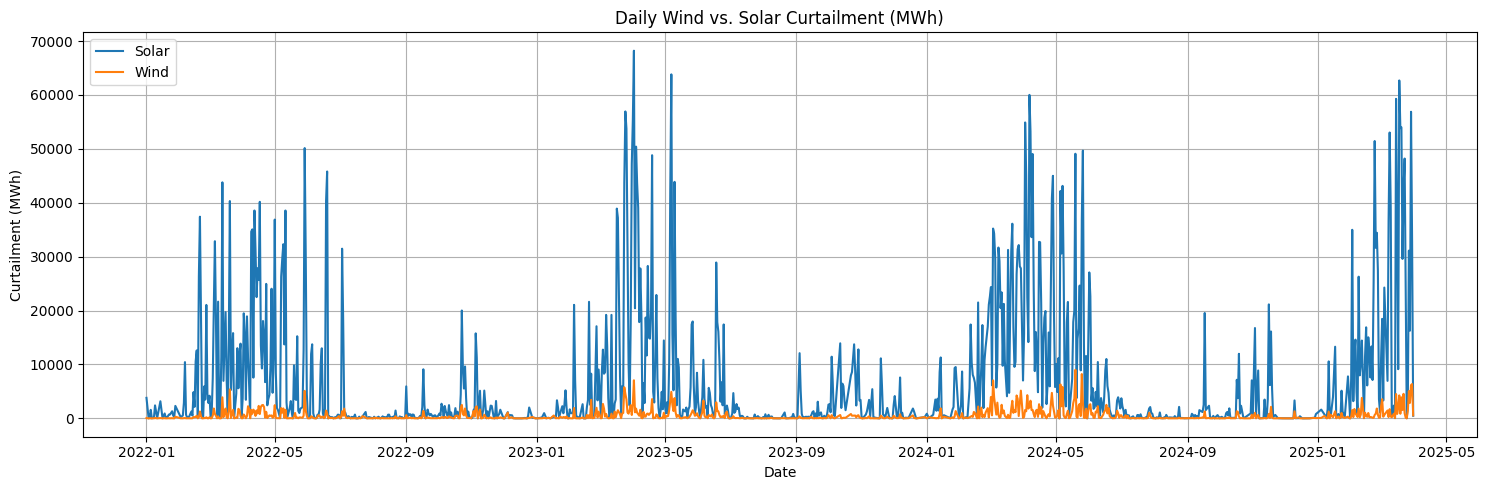

<Figure size 1200x600 with 0 Axes>

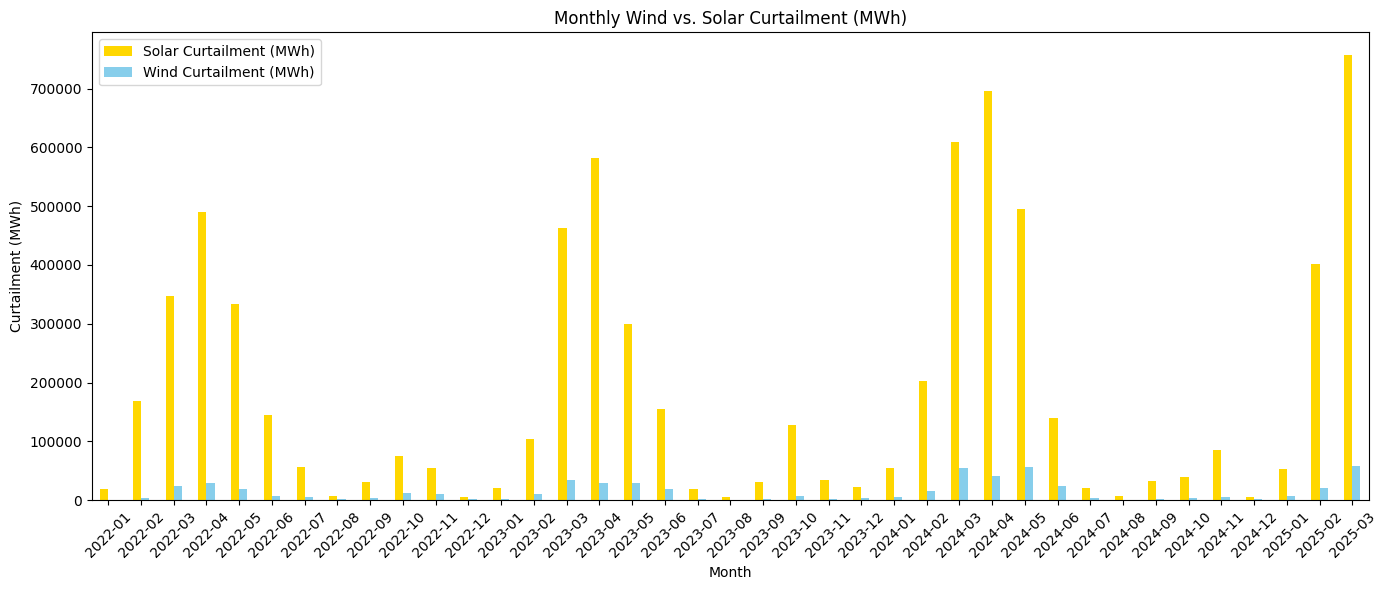

<Figure size 800x500 with 0 Axes>

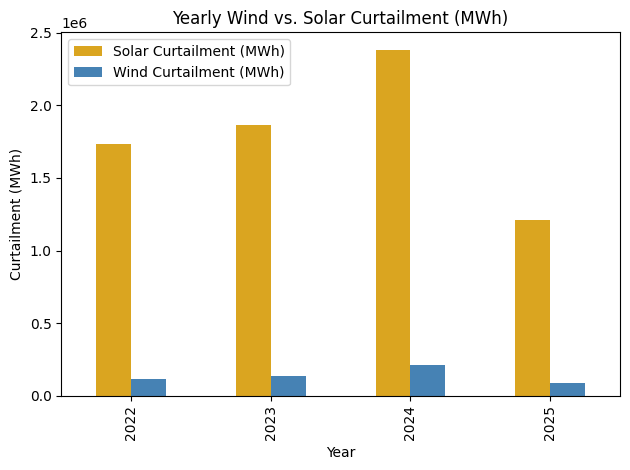

In [31]:
# Create aggregated views of solar and wind curtailment over time
# Drop rows with missing values to ensure clean aggregation
curtailment_df_clean = curtailment_df.copy()
curtailment_df_clean['Date'] = pd.to_datetime(curtailment_df_clean['Date'])
curtailment_df_clean = curtailment_df_clean.dropna(subset=['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)'])

# Daily totals
daily_curtailment = curtailment_df_clean.groupby(curtailment_df_clean['Date'].dt.date)[
    ['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)']
].sum().reset_index()

# Monthly totals
monthly_curtailment = curtailment_df_clean.groupby(curtailment_df_clean['Month'])[
    ['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)']
].sum().reset_index()

# Yearly totals
yearly_curtailment = curtailment_df_clean.groupby(curtailment_df_clean['Year'])[
    ['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)']
].sum().reset_index()

# Plot daily curtailment
plt.figure(figsize=(15, 5))
sns.lineplot(data=daily_curtailment, x='Date', y='Solar Curtailment (MWh)', label='Solar')
sns.lineplot(data=daily_curtailment, x='Date', y='Wind Curtailment (MWh)', label='Wind')
plt.title("Daily Wind vs. Solar Curtailment (MWh)")
plt.xlabel("Date")
plt.ylabel("Curtailment (MWh)")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

# Plot monthly curtailment
plt.figure(figsize=(12, 6))
monthly_curtailment['Month'] = monthly_curtailment['Month'].astype(str)  # for x-axis labels
monthly_curtailment.set_index('Month')[['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)']].plot(
    kind='bar', stacked=False, figsize=(14, 6), color=['gold', 'skyblue']
)
plt.title("Monthly Wind vs. Solar Curtailment (MWh)")
plt.xlabel("Month")
plt.ylabel("Curtailment (MWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot yearly curtailment
plt.figure(figsize=(8, 5))
yearly_curtailment.set_index('Year')[['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)']].plot(
    kind='bar', stacked=False, color=['goldenrod', 'steelblue']
)
plt.title("Yearly Wind vs. Solar Curtailment (MWh)")
plt.xlabel("Year")
plt.ylabel("Curtailment (MWh)")
plt.tight_layout()
plt.show()


In [32]:
# ---------------------------------------------
# STEP 4: Aggregate by Time and Reason
# ---------------------------------------------
daily = curtailment_df.groupby(['Datetime', 'Reason']).agg({
    'Solar Curtailment (MWh)': 'sum',
    'Wind Curtailment (MWh)': 'sum',
    'Total Curtailment (MW) (MWh)': 'sum'
}).reset_index()
daily['Date'] = daily['Datetime'].dt.date

# Monthly summary
curtailment_df['Month'] = curtailment_df['Datetime'].dt.to_period('M')
monthly = curtailment_df.groupby(['Month', 'Reason'])[
    ['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)', 'Total Curtailment (MW) (MWh)']
].sum().reset_index()

# Yearly summary
yearly = curtailment_df.groupby(['Year', 'Reason'])[
    ['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)', 'Total Curtailment (MW) (MWh)']
].sum().reset_index()

# Save output for next step
# daily.to_csv("../outputs/daily_curtailment_breakdown.csv", index=False)
# monthly.to_csv("../outputs/monthly_curtailment_breakdown.csv", index=False)
# yearly.to_csv("../outputs/yearly_curtailment_breakdown.csv", index=False)

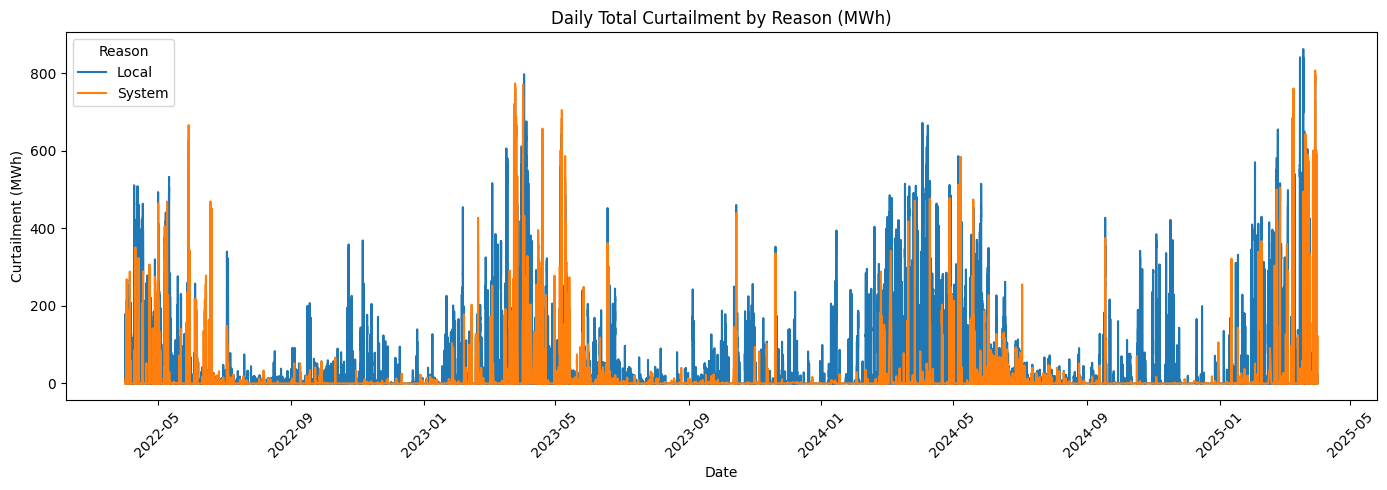

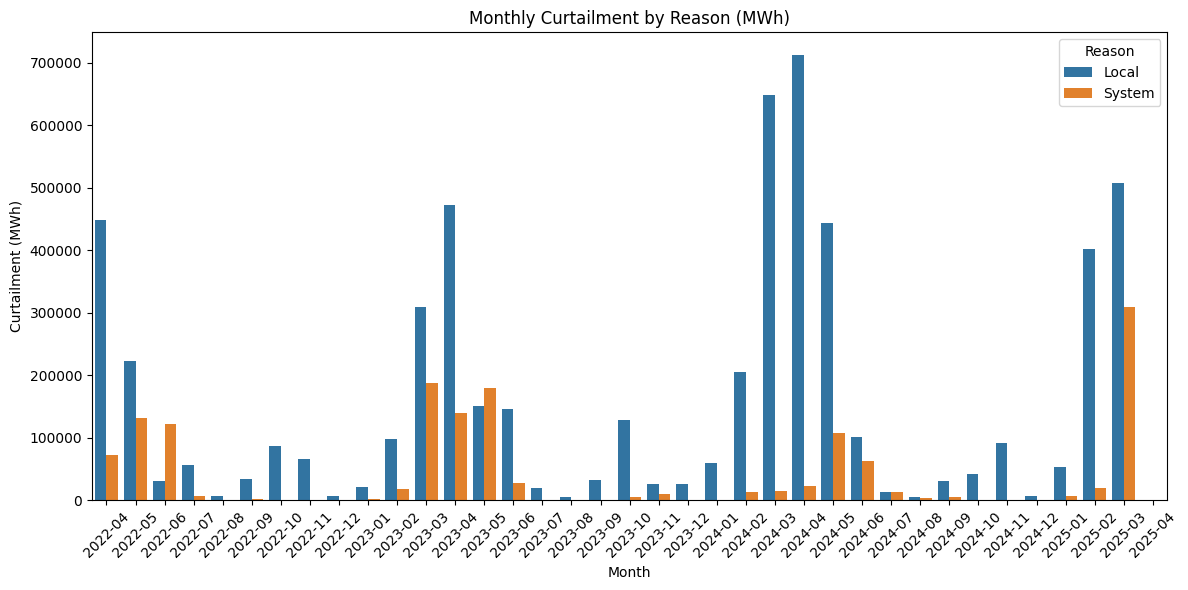

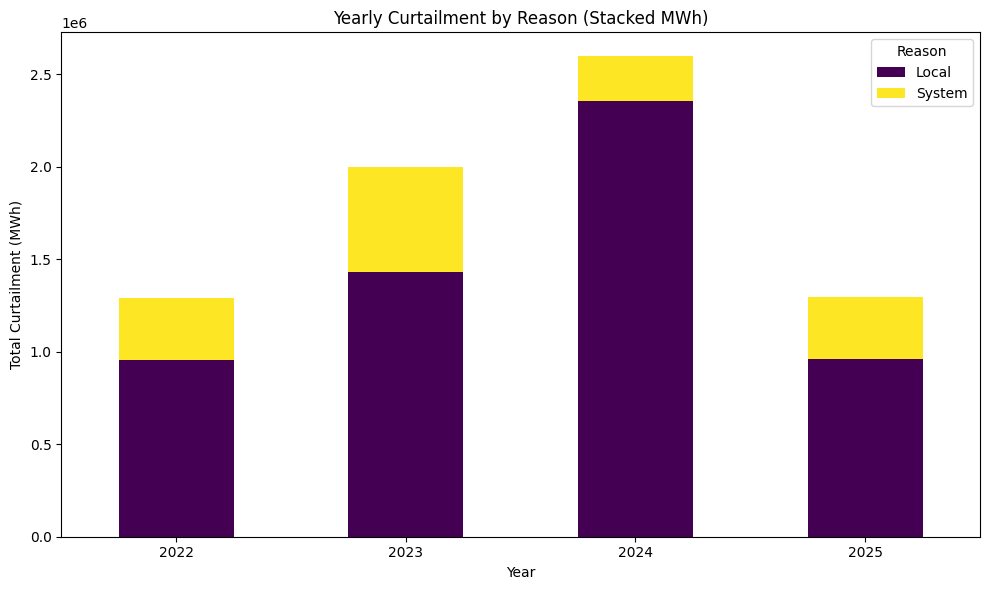

In [33]:
# ---------------------------------------------
# DAILY CURTAILMENT TRENDS
# ---------------------------------------------
plt.figure(figsize=(14, 5))
sns.lineplot(data=daily, x="Datetime", y="Total Curtailment (MW) (MWh)", hue="Reason")
plt.title("Daily Total Curtailment by Reason (MWh)")
plt.xlabel("Date")
plt.ylabel("Curtailment (MWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------------------------
# MONTHLY CURTAILMENT COMPARISON
# ---------------------------------------------
plt.figure(figsize=(12, 6))
sns.barplot(data=monthly, x="Month", y="Total Curtailment (MW) (MWh)", hue="Reason")
plt.title("Monthly Curtailment by Reason (MWh)")
plt.xlabel("Month")
plt.ylabel("Curtailment (MWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------------------------
# YEARLY CURTAILMENT STACKED BAR
# ---------------------------------------------
pivot_yearly = yearly.pivot(index="Year", columns="Reason", values="Total Curtailment (MW) (MWh)")
pivot_yearly.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")
plt.title("Yearly Curtailment by Reason (Stacked MWh)")
plt.xlabel("Year")
plt.ylabel("Total Curtailment (MWh)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [34]:
yearly_curtailment

,Year,Solar Curtailment (MWh),Wind Curtailment (MWh)
0,2022,1.733760e+06,117564.310791
1,2023,1.862576e+06,137096.106369
2,2024,2.384253e+06,212301.104495
3,2025,1.211974e+06,84235.807207


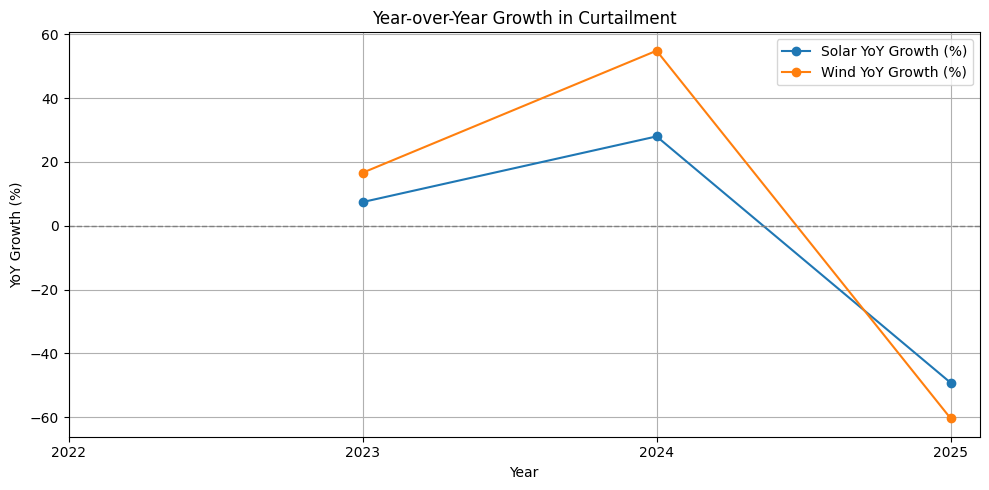

In [36]:
# Compute YoY growth
yearly_curtailment['Solar YoY Growth (%)'] = yearly_curtailment['Solar Curtailment (MWh)'].pct_change() * 100
yearly_curtailment['Wind YoY Growth (%)'] = yearly_curtailment['Wind Curtailment (MWh)'].pct_change() * 100

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(yearly_curtailment['Year'], yearly_curtailment['Solar YoY Growth (%)'], marker='o', label='Solar YoY Growth (%)')
plt.plot(yearly_curtailment['Year'], yearly_curtailment['Wind YoY Growth (%)'], marker='o', label='Wind YoY Growth (%)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

# Fix x-axis ticks
plt.xticks(yearly_curtailment['Year'])

plt.title('Year-over-Year Growth in Curtailment')
plt.xlabel('Year')
plt.ylabel('YoY Growth (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

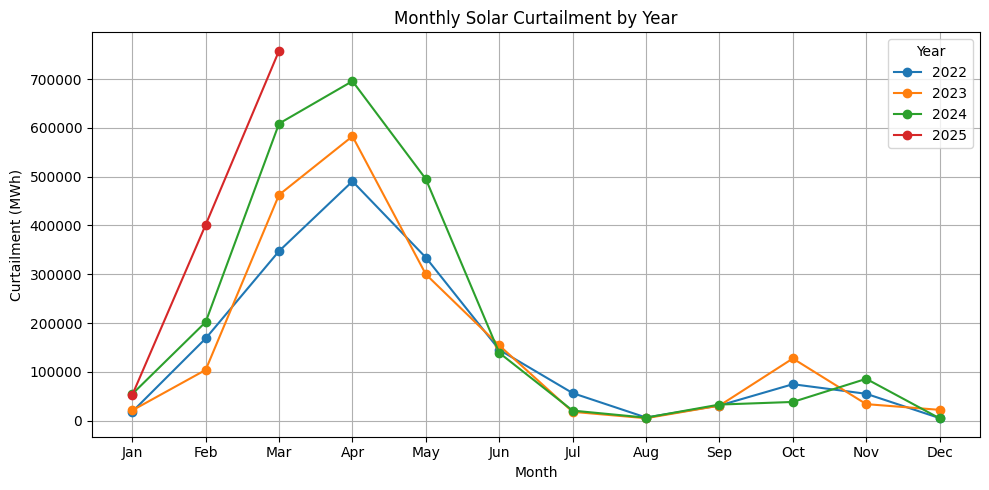

In [38]:
# Assume monthly_curtailment is already loaded
monthly_curtailment['Month'] = pd.to_datetime(monthly_curtailment['Month'])
monthly_curtailment['Year'] = monthly_curtailment['Month'].dt.year
monthly_curtailment['Month_Num'] = monthly_curtailment['Month'].dt.month

# Group by Year and Month_Num for Solar
pivot_solar = monthly_curtailment.pivot(index='Month_Num', columns='Year', values='Solar Curtailment (MWh)')

# Plot solar
plt.figure(figsize=(10, 5))
for year in pivot_solar.columns:
    plt.plot(pivot_solar.index, pivot_solar[year], marker='o', label=str(year))
plt.xticks(range(1,13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Monthly Solar Curtailment by Year')
plt.xlabel('Month')
plt.ylabel('Curtailment (MWh)')
plt.legend(title='Year')
plt.grid(True)
plt.tight_layout()
plt.show()

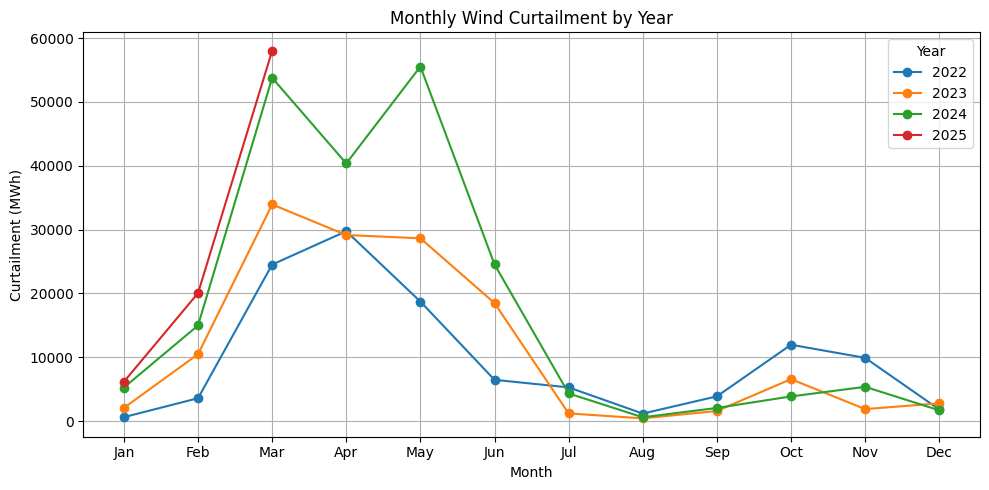

In [39]:
# Repeat for Wind
pivot_wind = monthly_curtailment.pivot(index='Month_Num', columns='Year', values='Wind Curtailment (MWh)')

plt.figure(figsize=(10, 5))
for year in pivot_wind.columns:
    plt.plot(pivot_wind.index, pivot_wind[year], marker='o', label=str(year))
plt.xticks(range(1,13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Monthly Wind Curtailment by Year')
plt.xlabel('Month')
plt.ylabel('Curtailment (MWh)')
plt.legend(title='Year')
plt.grid(True)
plt.tight_layout()
plt.show()

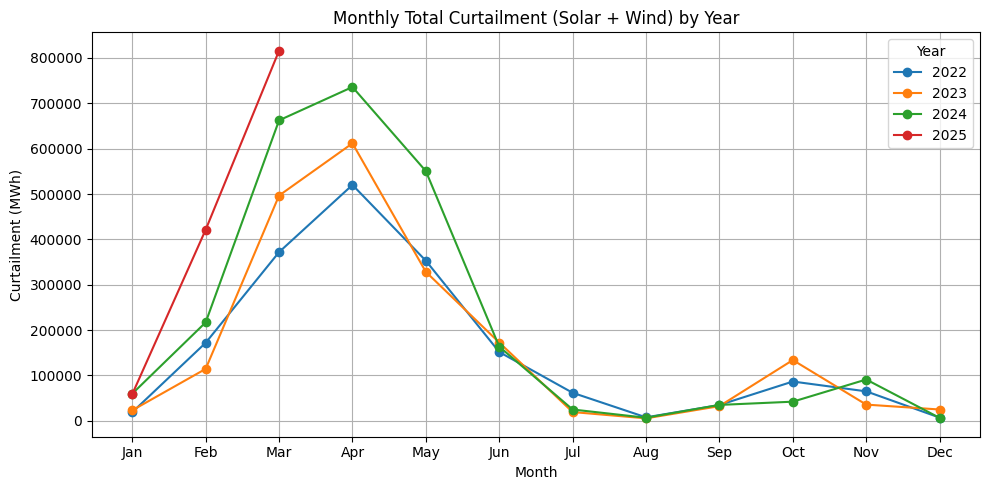

In [40]:
# Add a combined curtailment column
monthly_curtailment['Total Curtailment (MWh)'] = (
    monthly_curtailment['Solar Curtailment (MWh)'] + monthly_curtailment['Wind Curtailment (MWh)']
)

# Pivot for combined curtailment
pivot_total = monthly_curtailment.pivot(index='Month_Num', columns='Year', values='Total Curtailment (MWh)')

# Plot total curtailment
plt.figure(figsize=(10, 5))
for year in pivot_total.columns:
    plt.plot(pivot_total.index, pivot_total[year], marker='o', label=str(year))
plt.xticks(range(1,13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Monthly Total Curtailment (Solar + Wind) by Year')
plt.xlabel('Month')
plt.ylabel('Curtailment (MWh)')
plt.legend(title='Year')
plt.grid(True)
plt.tight_layout()
plt.show()

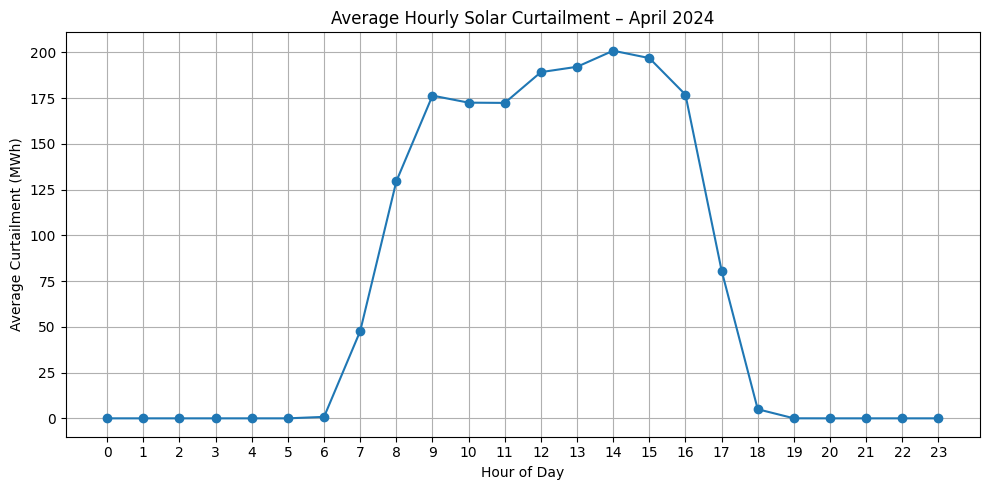

In [57]:
# Filter April 2024 data
#curtailment_df['Datetime'] = pd.to_datetime(curtailment_df['Datetime'])
curtailment_df['Datetime'] = curtailment_df['Datetime'] - pd.Timedelta(hours=7)

df_april = curtailment_df[curtailment_df['Datetime'].dt.month == 4]
df_april = df_april[df_april['Datetime'].dt.year == 2024]

# Extract hour and fill missing values
df_april['Hour'] = df_april['Datetime'].dt.hour
df_april['Solar Curtailment (MWh)'] = df_april['Solar Curtailment (MWh)'].fillna(0)

# Average solar curtailment per hour
avg_solar_by_hour = df_april.groupby('Hour')['Solar Curtailment (MWh)'].mean()

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(avg_solar_by_hour.index, avg_solar_by_hour.values, marker='o')
plt.title('Average Hourly Solar Curtailment – April 2024')
plt.xlabel('Hour of Day')
plt.ylabel('Average Curtailment (MWh)')
plt.grid(True)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


In [58]:
# ---------------------------------------------
# STEP 1: Load and Combine Yearly Excel Files (Production sheet)
# ---------------------------------------------
data_dir = Path("../data")
years = [2022, 2023, 2024, 2025]
production_combined = []

for year in years:
    file = data_dir / f"productionandcurtailmentsdata_{year}.xlsx"
    try:
        xl = pd.ExcelFile(file)
        df_prod = xl.parse("Production")
        df_prod['Year'] = year
        production_combined.append(df_prod)
    except Exception as e:
        print(f"Error loading {file.name}: {e}")

production_df = pd.concat(production_combined, ignore_index=True)

# Ensure 'Date' is parsed as datetime
production_df['Date'] = pd.to_datetime(production_df['Date'])

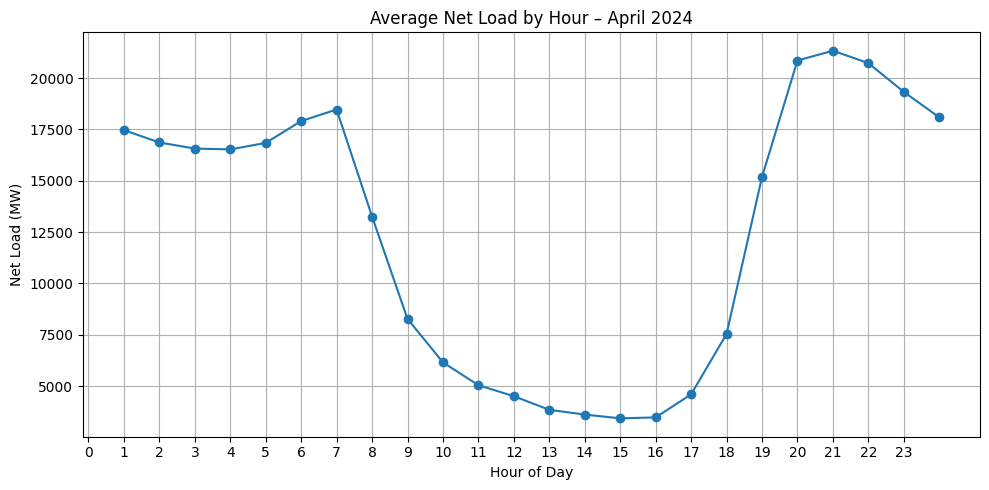

In [59]:
# Optionally filter to April 2024
production_df['Hour'] = production_df['Hour'].astype(int)
production_df_april = production_df[
    (production_df['Date'].dt.month == 4) & (production_df['Date'].dt.year == 2024)
]

# Group by hour, compute average net load
avg_net_load_by_hour = production_df_april.groupby('Hour')['Net Load'].mean()

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(avg_net_load_by_hour.index, avg_net_load_by_hour.values, marker='o')
plt.title('Average Net Load by Hour – April 2024')
plt.xlabel('Hour of Day')
plt.ylabel('Net Load (MW)')
plt.grid(True)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

1. Clear temporal patterns
Curtailment spikes midday → aligns with solar generation peak.
Spring months (especially April) show high average curtailment → matches real-world CAISO reports.
These point to strong seasonality + diurnal structure.

2. Year-over-year growth trend
Total curtailed MWh is increasing, especially for solar.
There’s a structural oversupply problem, not just a weather-driven one.

3. Curtailment timing aligns with net load dips, Midday → High Solar Output → Net Load Drops → Oversupply → Curtailment
Solar generation depresses net load during certain hours, creating curtailment pressure.

Curtailment is a forecastable quantity influenced by:
Time features (hour, month, weekday)

Supply capacity (installed solar/wind MW over time)

Demand (total load, net load trends)

Storage deployment (batteries reduce curtailment)